In [1]:
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import AdaBoostClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier


# ==========================================
# 1. Load Placement Prediction Dataset
# ==========================================
df = pd.read_csv("/content/Iris (2) (1).csv")

print("Dataset:")
print(df)

print("\nDataset Information:")
print(df.info())


Dataset:
      Id  SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm  \
0      1            5.1           3.5            1.4           0.2   
1      2            4.9           3.0            1.4           0.2   
2      3            4.7           3.2            1.3           0.2   
3      4            4.6           3.1            1.5           0.2   
4      5            5.0           3.6            1.4           0.2   
..   ...            ...           ...            ...           ...   
145  146            6.7           3.0            5.2           2.3   
146  147            6.3           2.5            5.0           1.9   
147  148            6.5           3.0            5.2           2.0   
148  149            6.2           3.4            5.4           2.3   
149  150            5.9           3.0            5.1           1.8   

            Species  
0       Iris-setosa  
1       Iris-setosa  
2       Iris-setosa  
3       Iris-setosa  
4       Iris-setosa  
..              ..

In [3]:
# ==========================================
# 2. Encode Categorical Columns
# ==========================================

# The original code attempted to encode 'Backlogs' and 'Placed' columns,
# but these columns do not exist in the loaded Iris dataset.
# The 'Species' column is the categorical column in the Iris dataset that needs encoding.

# Encode 'Species' column using LabelEncoder
le = LabelEncoder()
df["Species"] = le.fit_transform(df["Species"])

In [5]:
# ==========================================
# 3. Define Features and Target
# ==========================================

# 'Id' is excluded because it is only an identifier
# 'Species' is the target variable for the Iris dataset
X = df.drop(["Id", "Species"], axis=1)

y = df["Species"]


print("\nFeatures:")
print(X)

print("\nTarget:")
print(y)


Features:
     SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm
0              5.1           3.5            1.4           0.2
1              4.9           3.0            1.4           0.2
2              4.7           3.2            1.3           0.2
3              4.6           3.1            1.5           0.2
4              5.0           3.6            1.4           0.2
..             ...           ...            ...           ...
145            6.7           3.0            5.2           2.3
146            6.3           2.5            5.0           1.9
147            6.5           3.0            5.2           2.0
148            6.2           3.4            5.4           2.3
149            5.9           3.0            5.1           1.8

[150 rows x 4 columns]

Target:
0      0
1      0
2      0
3      0
4      0
      ..
145    2
146    2
147    2
148    2
149    2
Name: Species, Length: 150, dtype: int64


In [6]:
# ==========================================
# 4. Train-Validation Split
# ==========================================

X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)


print("\nTraining samples:", len(X_train))
print("Validation samples:", len(X_val))



Training samples: 105
Validation samples: 45


In [7]:
# ==========================================
# 4. Train-Validation Split
# ==========================================

X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)


print("\nTraining samples:", len(X_train))
print("Validation samples:", len(X_val))



Training samples: 105
Validation samples: 45


In [8]:
# ==========================================
# 5. Boosting Benchmark Function
# ==========================================

def boosting_benchmark(X_train, y_train, X_val, y_val):

    models = {

        "AdaBoost": AdaBoostClassifier(
            n_estimators=100,
            learning_rate=0.1,
            random_state=42
        ),

        "GBC": GradientBoostingClassifier(
            n_estimators=100,
            learning_rate=0.1,
            max_depth=3,
            random_state=42
        ),

        "XGB": XGBClassifier(
            n_estimators=100,
            learning_rate=0.1,
            max_depth=3,
            random_state=42,
            eval_metric="logloss"
        ),

        "LGB": LGBMClassifier(
            n_estimators=100,
            learning_rate=0.1,
            max_depth=3,
            random_state=42,
            verbosity=-1
        )
    }

    results = []

    for name, model in models.items():

        # Train model
        model.fit(X_train, y_train)

        # Predictions
        train_pred = model.predict(X_train)
        val_pred = model.predict(X_val)

        # Accuracy
        train_accuracy = accuracy_score(
            y_train,
            train_pred
        )

        val_accuracy = accuracy_score(
            y_val,
            val_pred
        )

        results.append({
            "model": name,
            "train_accuracy": train_accuracy,
            "val_accuracy": val_accuracy
        })

    # Convert to DataFrame
    results_df = pd.DataFrame(results)

    # Sort by validation accuracy
    results_df = results_df.sort_values(
        by="val_accuracy",
        ascending=False
    ).reset_index(drop=True)

    return results_df

In [9]:
# ==========================================
# 6. Run Benchmark
# ==========================================

results = boosting_benchmark(
    X_train,
    y_train,
    X_val,
    y_val
)

In [10]:
# ==========================================
# 7. Display Results
# ==========================================

print("\nBoosting Benchmark Results:")
print(results)


Boosting Benchmark Results:
      model  train_accuracy  val_accuracy
0  AdaBoost        0.971429      0.933333
1       GBC        1.000000      0.933333
2       XGB        1.000000      0.933333
3       LGB        1.000000      0.844444


In [12]:
# ============================================================
# BOOSTING BENCHMARK - PLACEMENT PREDICTION
# ============================================================

import pandas as pd
import numpy as np
import time
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import AdaBoostClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

import shap


# ============================================================
# 1. LOAD DATASET
# ============================================================

df = pd.read_csv("/content/Iris (2) (1).csv")

print("Dataset:")
print(df)

Dataset:
      Id  SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm  \
0      1            5.1           3.5            1.4           0.2   
1      2            4.9           3.0            1.4           0.2   
2      3            4.7           3.2            1.3           0.2   
3      4            4.6           3.1            1.5           0.2   
4      5            5.0           3.6            1.4           0.2   
..   ...            ...           ...            ...           ...   
145  146            6.7           3.0            5.2           2.3   
146  147            6.3           2.5            5.0           1.9   
147  148            6.5           3.0            5.2           2.0   
148  149            6.2           3.4            5.4           2.3   
149  150            5.9           3.0            5.1           1.8   

            Species  
0       Iris-setosa  
1       Iris-setosa  
2       Iris-setosa  
3       Iris-setosa  
4       Iris-setosa  
..              ..

In [21]:
# ============================================================
# 2. ENCODE CATEGORICAL VARIABLES
# ============================================================

# The Iris dataset does not contain 'Backlogs' or 'Placed' columns.
# The 'Species' column was already encoded in a previous cell.
# However, the dataset was reloaded in HeWVlY17c1Sj, overwriting the encoding.
# Re-encode 'Species' column to ensure numerical labels for XGBoost.
le = LabelEncoder()
df["Species"] = le.fit_transform(df["Species"])


In [22]:
# ============================================================
# 3. FEATURES AND TARGET
# ============================================================

# 'Id' is excluded because it is only an identifier
# 'Species' is the target variable for the Iris dataset
X = df.drop(["Id", "Species"], axis=1)

y = df["Species"]

print("\nFeatures:")
print(X)

print("\nTarget:")
print(y)



Features:
     SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm
0              5.1           3.5            1.4           0.2
1              4.9           3.0            1.4           0.2
2              4.7           3.2            1.3           0.2
3              4.6           3.1            1.5           0.2
4              5.0           3.6            1.4           0.2
..             ...           ...            ...           ...
145            6.7           3.0            5.2           2.3
146            6.3           2.5            5.0           1.9
147            6.5           3.0            5.2           2.0
148            6.2           3.4            5.4           2.3
149            5.9           3.0            5.1           1.8

[150 rows x 4 columns]

Target:
0      0
1      0
2      0
3      0
4      0
      ..
145    2
146    2
147    2
148    2
149    2
Name: Species, Length: 150, dtype: int64


In [23]:
  # ============================================================
# 4. TRAIN / VALIDATION SPLIT
# ============================================================

X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

print("\nTraining samples:", len(X_train))
print("Validation samples:", len(X_val))



Training samples: 105
Validation samples: 45


In [18]:
# ============================================================
# 5. ADABOOST - SAMPLE WEIGHTS
# ============================================================

ada = AdaBoostClassifier(
    n_estimators=10,
    learning_rate=0.5,
    random_state=42
)

# Initial equal weights
initial_weights = np.ones(len(X_train)) / len(X_train)

print("\nInitial AdaBoost sample weights:")
print(initial_weights)

ada.fit(X_train, y_train)

# Prediction
ada_pred = ada.predict(X_val)

print("\nAdaBoost Validation Accuracy:",
      accuracy_score(y_val, ada_pred))



Initial AdaBoost sample weights:
[0.00952381 0.00952381 0.00952381 0.00952381 0.00952381 0.00952381
 0.00952381 0.00952381 0.00952381 0.00952381 0.00952381 0.00952381
 0.00952381 0.00952381 0.00952381 0.00952381 0.00952381 0.00952381
 0.00952381 0.00952381 0.00952381 0.00952381 0.00952381 0.00952381
 0.00952381 0.00952381 0.00952381 0.00952381 0.00952381 0.00952381
 0.00952381 0.00952381 0.00952381 0.00952381 0.00952381 0.00952381
 0.00952381 0.00952381 0.00952381 0.00952381 0.00952381 0.00952381
 0.00952381 0.00952381 0.00952381 0.00952381 0.00952381 0.00952381
 0.00952381 0.00952381 0.00952381 0.00952381 0.00952381 0.00952381
 0.00952381 0.00952381 0.00952381 0.00952381 0.00952381 0.00952381
 0.00952381 0.00952381 0.00952381 0.00952381 0.00952381 0.00952381
 0.00952381 0.00952381 0.00952381 0.00952381 0.00952381 0.00952381
 0.00952381 0.00952381 0.00952381 0.00952381 0.00952381 0.00952381
 0.00952381 0.00952381 0.00952381 0.00952381 0.00952381 0.00952381
 0.00952381 0.00952381 0.009

In [19]:
# ============================================================
# 6. DISPLAY ADABOOST ESTIMATOR WEIGHTS
# ============================================================

print("\nAdaBoost estimator weights:")

for i, weight in enumerate(ada.estimator_weights_):
    print(f"Estimator {i + 1}: {weight:.4f}")


AdaBoost estimator weights:
Estimator 1: 0.6931
Estimator 2: 0.8585
Estimator 3: 0.9568
Estimator 4: 0.7306
Estimator 5: 0.9016
Estimator 6: 0.9409
Estimator 7: 0.7764
Estimator 8: 0.8859
Estimator 9: 0.8430
Estimator 10: 0.8227


In [24]:
# ============================================================
# 7. XGBOOST WITH EARLY STOPPING
# ============================================================

xgb = XGBClassifier(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=3,
    random_state=42,
    eval_metric="mlogloss", # Use mlogloss for multi-class classification
    early_stopping_rounds=20
)

xgb.fit(
    X_train,
    y_train,
    eval_set=[(X_val, y_val)],
    verbose=False
)

xgb_pred = xgb.predict(X_val)

print("\nXGBoost Validation Accuracy:",
      accuracy_score(y_val, xgb_pred))

print("Best XGBoost iteration:",
      xgb.best_iteration)



XGBoost Validation Accuracy: 0.9333333333333333
Best XGBoost iteration: 98


In [25]:
# ============================================================
# 8. LIGHTGBM - TRAINING TIME
# ============================================================

lgb = LGBMClassifier(
    n_estimators=100,
    learning_rate=0.05,
    max_depth=3,
    random_state=42,
    verbosity=-1
)

start_time = time.perf_counter()

lgb.fit(X_train, y_train)

end_time = time.perf_counter()

lgb_time = end_time - start_time

lgb_pred = lgb.predict(X_val)

print("\nLightGBM Validation Accuracy:",
      accuracy_score(y_val, lgb_pred))

print(f"LightGBM Training Time: {lgb_time:.6f} seconds")


LightGBM Validation Accuracy: 0.8666666666666667
LightGBM Training Time: 0.016818 seconds


<Figure size 800x500 with 0 Axes>

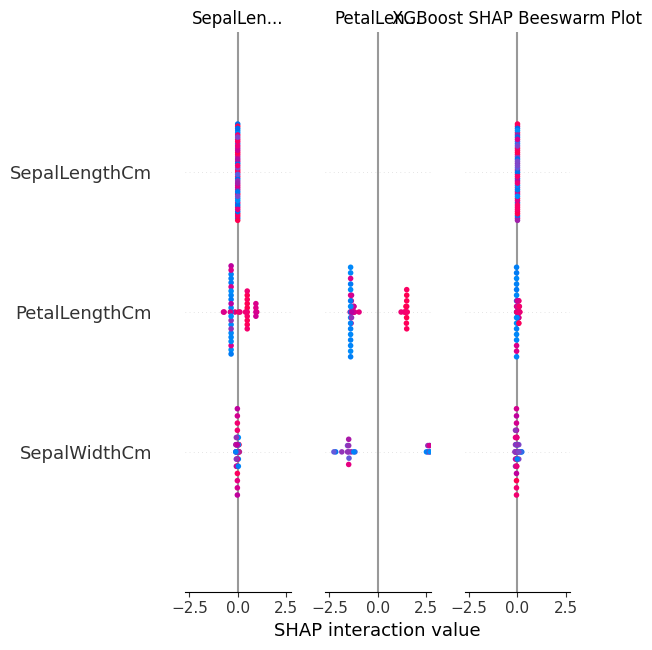

In [26]:
# ============================================================
# 9. SHAP BEESWARM - XGBOOST
# ============================================================

explainer = shap.TreeExplainer(xgb)

shap_values = explainer.shap_values(X_val)

plt.figure(figsize=(8, 5))

shap.summary_plot(
    shap_values,
    X_val,
    plot_type="dot",
    show=False
)

plt.title("XGBoost SHAP Beeswarm Plot")
plt.tight_layout()
plt.show()


In [27]:
# ============================================================
# 10. BOOSTING BENCHMARK FUNCTION
# ============================================================

def boosting_benchmark(X_train, y_train, X_val, y_val):

    models = {

        "AdaBoost": AdaBoostClassifier(
            n_estimators=100,
            learning_rate=0.1,
            random_state=42
        ),

        "GBC": GradientBoostingClassifier(
            n_estimators=100,
            learning_rate=0.1,
            max_depth=3,
            random_state=42
        ),

        "XGB": XGBClassifier(
            n_estimators=100,
            learning_rate=0.1,
            max_depth=3,
            random_state=42,
            eval_metric="logloss"
        ),

        "LGB": LGBMClassifier(
            n_estimators=100,
            learning_rate=0.1,
            max_depth=3,
            random_state=42,
            verbosity=-1
        )
    }

    results = []

    for name, model in models.items():

        start_time = time.perf_counter()

        model.fit(X_train, y_train)

        end_time = time.perf_counter()

        train_time = end_time - start_time

        train_pred = model.predict(X_train)
        val_pred = model.predict(X_val)

        train_accuracy = accuracy_score(
            y_train,
            train_pred
        )

        val_accuracy = accuracy_score(
            y_val,
            val_pred
        )

        results.append({
            "model": name,
            "train_accuracy": train_accuracy,
            "val_accuracy": val_accuracy,
            "training_time_sec": train_time
        })

    results_df = pd.DataFrame(results)

    # Sort by validation accuracy
    results_df = results_df.sort_values(
        by="val_accuracy",
        ascending=False
    ).reset_index(drop=True)

    return results_df

In [28]:
# ============================================================
# 11. RUN BOOSTING BENCHMARK
# ============================================================

results = boosting_benchmark(
    X_train,
    y_train,
    X_val,
    y_val
)

print("\n==========================================")
print("BOOSTING BENCHMARK RESULTS")
print("==========================================")

print(results)


BOOSTING BENCHMARK RESULTS
      model  train_accuracy  val_accuracy  training_time_sec
0  AdaBoost        0.971429      0.933333           0.260824
1       GBC        1.000000      0.933333           0.665325
2       XGB        1.000000      0.933333           0.111800
3       LGB        1.000000      0.844444           0.032302


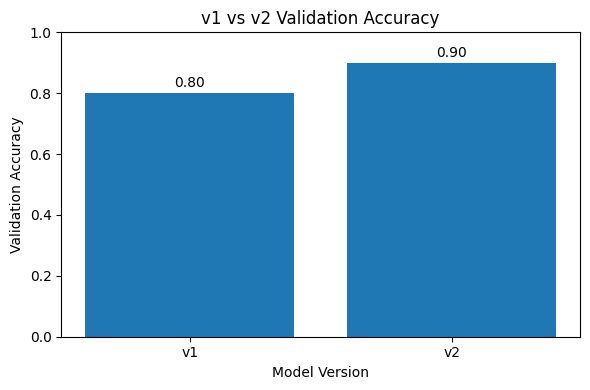

In [29]:
# ============================================================
# 12. V1 vs V2 BAR CHART
# ============================================================

# Example:
# v1 = baseline model
# v2 = improved model

# Replace these values with your actual results
v1_accuracy = 0.80
v2_accuracy = 0.90

versions = ["v1", "v2"]
accuracies = [v1_accuracy, v2_accuracy]

plt.figure(figsize=(6, 4))

plt.bar(
    versions,
    accuracies
)

plt.ylabel("Validation Accuracy")
plt.xlabel("Model Version")
plt.title("v1 vs v2 Validation Accuracy")

plt.ylim(0, 1)

for i, value in enumerate(accuracies):
    plt.text(
        i,
        value + 0.02,
        f"{value:.2f}",
        ha="center"
    )

plt.tight_layout()
plt.show()